In [2]:
!python -m pip install pandas corus nltk scikit-learn seaborn matplotlib

  Using cached pandas-2.3.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (91 kB)
  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (31 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached click-8.1.8-py3-none-any.whl.metadata (2.3 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached regex-2026.1.15-cp39-cp39-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl.meta

In [1]:
!curl -L -O https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  502M  100  502M    0     0  6349k      0  0:01:21  0:01:21 --:--:-- 7054k:00:48 11.0M01:01  0:00:17  0:00:44 5358k7953k      0  0:01:04  0:00:20  0:00:44 5379k00:22  0:00:44 5296k      0  0:01:18  0:01:00  0:00:18 8115k


In [ ]:
nltk.download('stopwords')

# Библиотеки + сид

In [1]:
import re
import os
import urllib.request

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import numpy as np
from corus import load_lenta

from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

In [2]:
RANDOM_STATE = 23

# EDA

In [3]:
path = 'lenta-ru-news.csv.gz' 
records = load_lenta(path)

data =[]
for record in records:
    data.append({
        'title': record.title,
        'text': record.text,
        'topic': record.topic
    })
    
df = pd.DataFrame(data)

Посмотрим сколько у нас пустых топиков и удалим их

In [4]:
initial_count = len(df)
print(f"Всего записей {initial_count}")

df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

print("\nПропуски")
print(df.isna().sum())

Всего записей 739351

Пропуски
title      0
text       5
topic    203
dtype: int64


In [5]:
df = df.dropna(subset=['topic'])

Посмотрим на распределение новостей по каждой теме

topic
Россия               160519
Мир                  136680
Экономика             79538
Спорт                 64421
Культура              53803
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44675
Из жизни              27611
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64


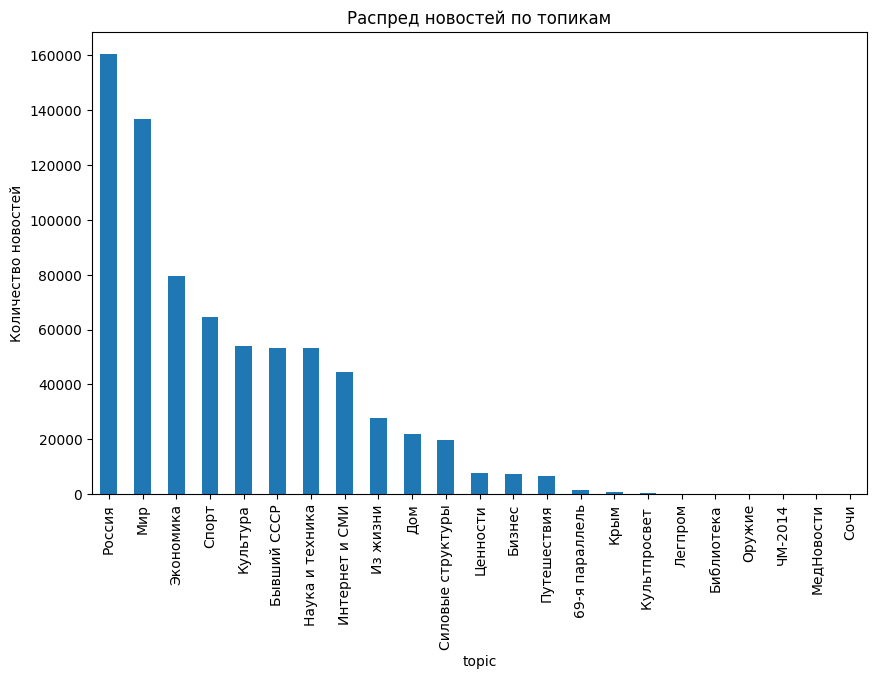

In [6]:
topic_counts = df['topic'].value_counts()
print(topic_counts)

plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar')
plt.title('Распред новостей по топикам')
plt.ylabel('Количество новостей')
plt.show()

Мне часто высвечивался warning при разделении данных в сплитах, мол слишком мало новостей для какого-то топика (stratify жаловался). Принял решение отсеять топики по кол-ву новостей

In [7]:
counts = df['topic'].value_counts()
valid_topics = counts[counts >= 100].index

df_clean = df[df['topic'].isin(valid_topics)]

print("Размер", df_clean.shape)

Размер (739076, 3)


Берем 100к текстов, так как ТЗ

In [8]:
df_sample, _ = train_test_split(
    df_clean,
    train_size=100000, 
    random_state=RANDOM_STATE, 
    stratify=df_clean['topic']
)

df_sample = df_sample.reset_index(drop=True)

print("Размер", df_sample.shape)

Размер (100000, 3)


1) сделал очистику и нормализацию от знаков препинания, цифр и так далее через регулярки
2) скачал стоп слова на русском и удалил их (это предлоги, местоимения и так далее)
3) слил заголовок и описание текста, мне кажется это даст больше информативности, хотя без этой фичи я не тестил
4) Я взял стемминг вместо лемматизация, потому что существенно быстрее + нам тут ничего особенного и не нужно, так как сами модели у нас линейные. В среднем делает за 4 минуты 24 секунды, что как будто бы нормально

In [9]:
stop_words = set(stopwords.words('russian'))
stemmer = SnowballStemmer("russian")

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яёa-z]', ' ', text)
    tokens = text.split()
    tokens =[stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df_sample['full_text'] = df_sample['title'] + " " + df_sample['text']

df_sample['processed_text'] = df_sample['full_text'].apply(preprocess_text)

Базовая разбивка также по ТЗ

In [10]:
X = df_sample['processed_text']
y = df_sample['topic']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.4, 
    random_state=RANDOM_STATE, 
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=RANDOM_STATE, 
    stratify=y_temp
)

# Обучение моделей без тюнинга гиперпараметров

## Baseline

In [11]:
dummy_clf = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)

y_pred_dummy = dummy_clf.predict(X_val)
print("Baseline\n", classification_report(y_val, y_pred_dummy, zero_division=0))

Baseline
                    precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00        34
           Бизнес       0.00      0.00      0.00       200
      Бывший СССР       0.07      0.07      0.07      1445
              Дом       0.01      0.01      0.01       588
         Из жизни       0.04      0.04      0.04       747
   Интернет и СМИ       0.06      0.06      0.06      1209
             Крым       0.00      0.00      0.00        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.07      0.08      0.08      1456
          Легпром       0.00      0.00      0.00         3
              Мир       0.18      0.18      0.18      3699
  Наука и техника       0.07      0.07      0.07      1438
      Путешествия       0.01      0.01      0.01       173
           Россия       0.22      0.21      0.21      4344
Силовые структуры       0.03      0.03      0.03       531
            Спорт       0.08      0.08      0

Результаты закономерно тоже dummy :D

## CountVectorizer

In [12]:
pipe_count = Pipeline([
    ('vect', CountVectorizer()),
    ('clf', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))
])

pipe_count.fit(X_train, y_train)
y_pred_count = pipe_count.predict(X_val)
print("Countvector\n", classification_report(y_val, y_pred_count, zero_division=0))

Countvector
                    precision    recall  f1-score   support

   69-я параллель       0.56      0.44      0.49        34
           Бизнес       0.55      0.44      0.49       200
      Бывший СССР       0.81      0.83      0.82      1445
              Дом       0.81      0.81      0.81       588
         Из жизни       0.60      0.63      0.61       747
   Интернет и СМИ       0.73      0.72      0.72      1209
             Крым       0.50      0.33      0.40        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.86      0.86      0.86      1456
          Легпром       0.33      0.33      0.33         3
              Мир       0.81      0.81      0.81      3699
  Наука и техника       0.83      0.82      0.82      1438
      Путешествия       0.73      0.76      0.75       173
           Россия       0.80      0.79      0.79      4344
Силовые структуры       0.54      0.57      0.55       531
            Спорт       0.97      0.96    

precision + recall какие то печальные

## TfidfVectorizer

In [13]:
pipe_tfidf = Pipeline([
    ('vect', TfidfVectorizer()),
    ('clf', LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000))
])

pipe_tfidf.fit(X_train, y_train)
y_pred_tfidf = pipe_tfidf.predict(X_val)
print("tfidf\n", classification_report(y_val, y_pred_tfidf, zero_division=0))

tfidf
                    precision    recall  f1-score   support

   69-я параллель       0.45      0.62      0.52        34
           Бизнес       0.39      0.62      0.48       200
      Бывший СССР       0.77      0.86      0.81      1445
              Дом       0.73      0.85      0.79       588
         Из жизни       0.51      0.73      0.60       747
   Интернет и СМИ       0.73      0.77      0.75      1209
             Крым       0.24      0.67      0.35        18
    Культпросвет        0.12      0.11      0.12         9
         Культура       0.85      0.89      0.87      1456
          Легпром       1.00      0.33      0.50         3
              Мир       0.85      0.77      0.81      3699
  Наука и техника       0.83      0.81      0.82      1438
      Путешествия       0.51      0.83      0.64       173
           Россия       0.86      0.70      0.77      4344
Силовые структуры       0.45      0.69      0.55       531
            Спорт       0.96      0.96      0.96

recall тут сильно лучше

# TFIDF тюннинг гиперпараметров

Если честно из всех результатов лучше TFIDF, так как у него recall 0.72, а у countvector 0.65. Так что будем дальше с tfidf работать

Гиперпараметры:
1) кол во фолдов взял 3
2) `ngram_range`, взял биграммы, триграммы не рискнул, так как и так большая нагрузка на ноутбук была
3) `min_df`, чтобы отсеять какие-то слова, которые не ключевые для определения тематики
4) `max_df`, чтобы убрать самые частые слова
5) `sublinear_tf`, чтобы снизить выбросы
6) `C`, собственно регуляризация

In [14]:
param_grid = {
    'vect__ngram_range': [(1, 1), (1, 2)],
    'vect__min_df': [10, 50],
    'vect__max_df': [0.7, 0.9],
    'vect__sublinear_tf': [True],
    'clf__C': [0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=pipe_tfidf, 
    param_grid=param_grid, 
    cv=3, 
    scoring='f1_weighted', 
    n_jobs=3, 
    verbose=2
)

grid.fit(X_train, y_train)

print("best params", grid.best_params_)
print("Лучший score", grid.best_score_)
best_model = grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=   7.1s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=   7.2s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=   7.5s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 2), vect__sublinear_tf=True; total time=  19.0s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 2), vect__sublinear_tf=True; total time=  18.8s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=10, vect__ngram_range=(1, 2), vect__sublinear_tf=True; total time=  19.5s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=50, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=   5.6s


/Users/iamnoob/Desktop/NLP_hw/hw_1/.venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=50, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=   6.2s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=50, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=   6.0s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=50, vect__ngram_range=(1, 2), vect__sublinear_tf=True; total time=  12.3s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=50, vect__ngram_range=(1, 2), vect__sublinear_tf=True; total time=  12.9s
[CV] END clf__C=0.1, vect__max_df=0.7, vect__min_df=50, vect__ngram_range=(1, 2), vect__sublinear_tf=True; total time=  12.8s
[CV] END clf__C=0.1, vect__max_df=0.9, vect__min_df=10, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=   6.6s
[CV] END clf__C=0.1, vect__max_df=0.9, vect__min_df=10, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=   6.6s
[CV] END clf__C=0.1, vect__max_df=0.9, vect__min_df=10, vect__ngram_range=(1, 1), vect__sublinear_tf=True; total time=

In [15]:
y_pred_test = best_model.predict(X_test)
print("predict\n", classification_report(y_test, y_pred_test, zero_division=0))

predict
                    precision    recall  f1-score   support

   69-я параллель       0.78      0.71      0.75        35
           Бизнес       0.61      0.48      0.54       200
      Бывший СССР       0.82      0.89      0.86      1445
              Дом       0.82      0.87      0.85       589
         Из жизни       0.63      0.68      0.66       747
   Интернет и СМИ       0.77      0.75      0.76      1209
             Крым       0.44      0.39      0.41        18
    Культпросвет        1.00      0.22      0.36         9
         Культура       0.88      0.90      0.89      1456
          Легпром       0.50      0.33      0.40         3
              Мир       0.83      0.83      0.83      3698
  Наука и техника       0.83      0.85      0.84      1438
      Путешествия       0.68      0.74      0.71       174
           Россия       0.84      0.80      0.82      4344
Силовые структуры       0.63      0.68      0.65       530
            Спорт       0.97      0.96      0.

Несмотря на то что accuracy вырос на 3%, precision+F1 выросли сильно! И это круто, значит в общем и целом мы стали лучше.

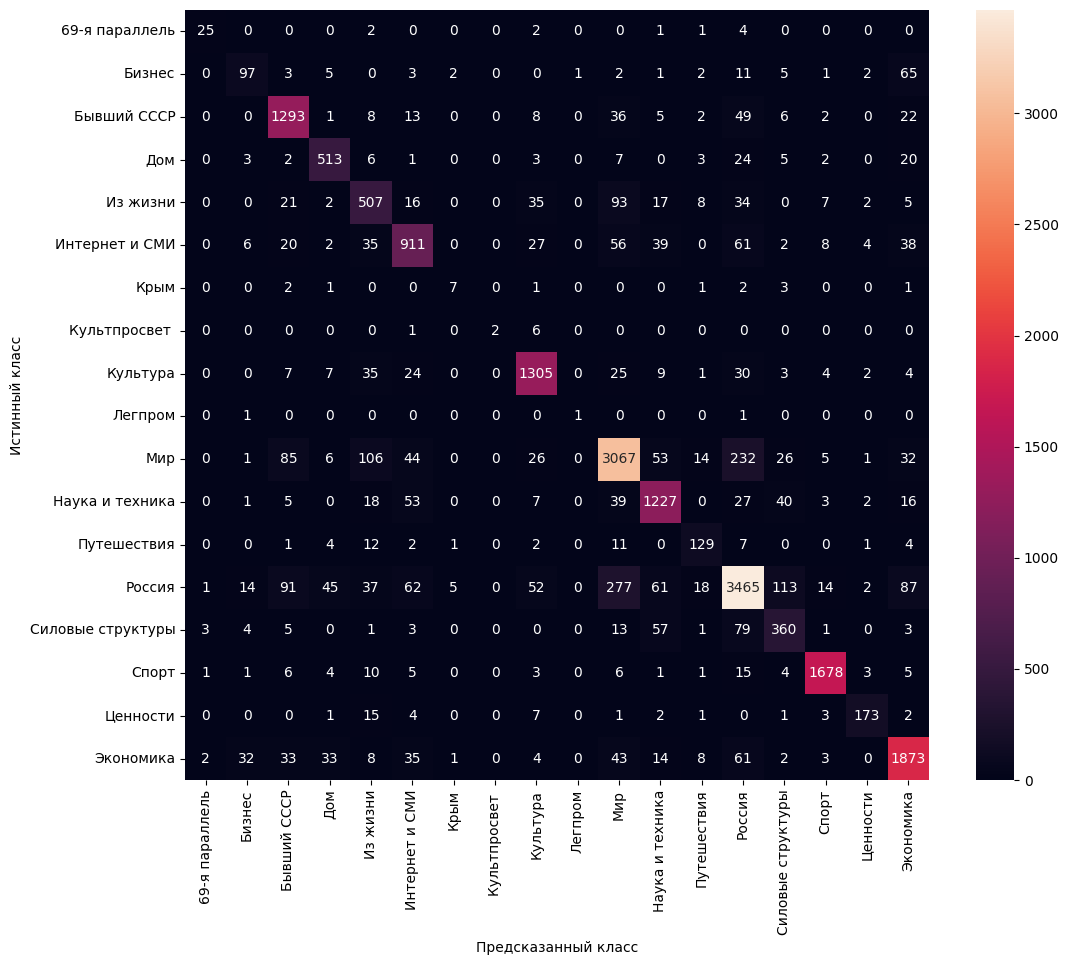

In [16]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

Забавно что топики "Бизнес", "Из жизни" выпали, видимо там слишком общие слова+много пересечений с дргуими и модель не справляется, чтобы отнести к этой тематике. Если посмотреть по картинке, то так и видно, что "Экономика" забрала у "Бизнеса" 65 новостей. Даже тут экономика что-то отбирает у бизнеса, как в жизни прям

"Силовые структуры" тоже забавно, так как 57 вообще-то почему-то ушло в "Наука и техника". В "Россия" ушло 79, но тут еще логично

Тут еще есть примеры, по которым видно, что просто другой класс забирает у нас новости из-за схожести слов.

Наверное тут только справится что-то сильнее, по типу BERT.